In [10]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch06/wine.csv'
df = pd.read_csv(url)
print(df[['Wine', 'Alcohol', 'Malic.acid']].head( ))



   Wine  Alcohol  Malic.acid
0     1    14.23        1.71
1     1    13.20        1.78
2     1    13.16        2.36
3     1    14.37        1.95
4     1    13.24        2.59


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(df.drop(
		'Wine', axis = 1), df['Wine'], test_size = 0.3, random_state = 0)

scaler = MinMaxScaler( )

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert scaled arrays back to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled,
					columns = X_train.columns, index = X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,
					columns = X_test.columns,  index = X_test.index)

# print first few rows
print(X_train_scaled_df[['Alcohol', 'Malic.acid']].head( ))


      Alcohol  Malic.acid
22   0.720430    0.203782
108  0.319892    0.084034
175  0.602151    0.712185
145  0.572581    0.563025
71   0.760753    0.130252


In [13]:
import numpy as np
np.round(X_train_scaled_df.describe(), 1)

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0
mean,0.5,0.3,0.5,0.5,0.3,0.4,0.5,0.4,0.4,0.4,0.4,0.5,0.4
std,0.2,0.2,0.1,0.2,0.2,0.2,0.3,0.2,0.2,0.2,0.2,0.3,0.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.4,0.2,0.5,0.3,0.2,0.2,0.2,0.3,0.3,0.2,0.2,0.2,0.2
50%,0.5,0.2,0.5,0.5,0.3,0.4,0.5,0.4,0.4,0.3,0.4,0.6,0.3
75%,0.7,0.5,0.6,0.6,0.4,0.6,0.7,0.6,0.5,0.5,0.5,0.7,0.5
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


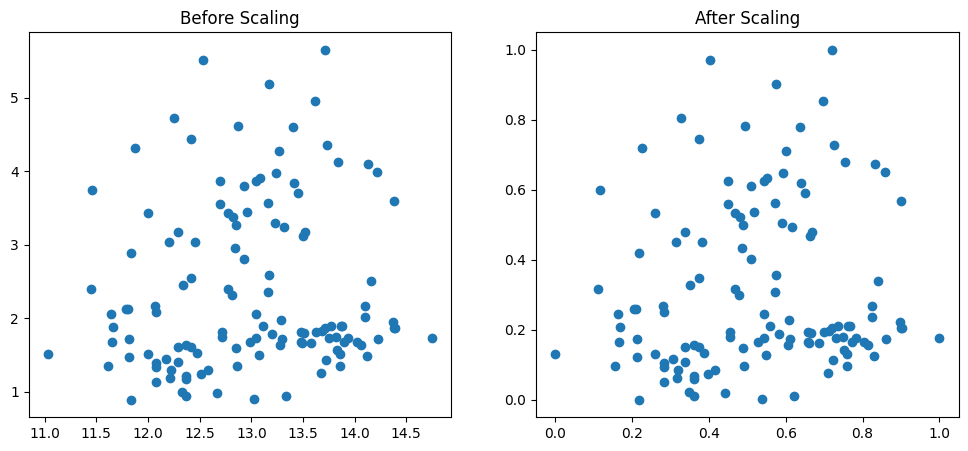

In [16]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic.acid'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled_df['Alcohol'], X_train_scaled_df['Malic.acid'])
ax2.set_title("After Scaling")
plt.show()

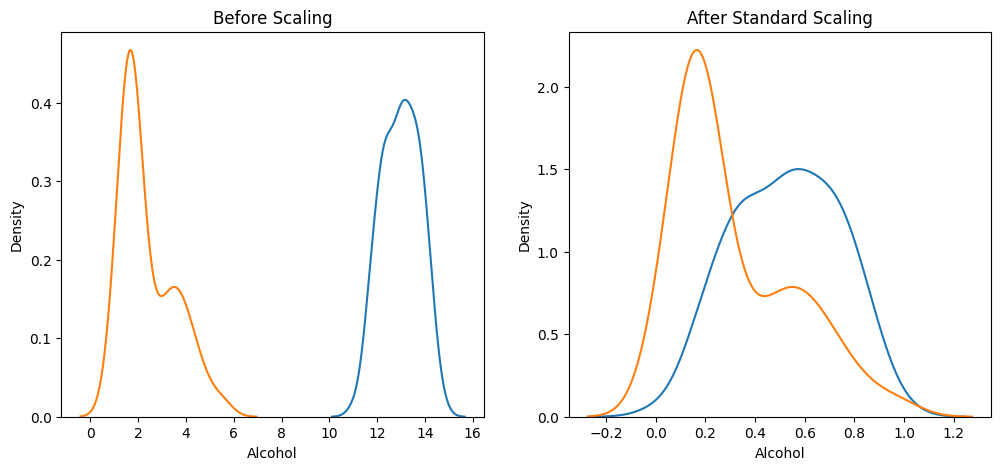

In [18]:
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic.acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled_df['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled_df['Malic.acid'], ax=ax2)
plt.show()

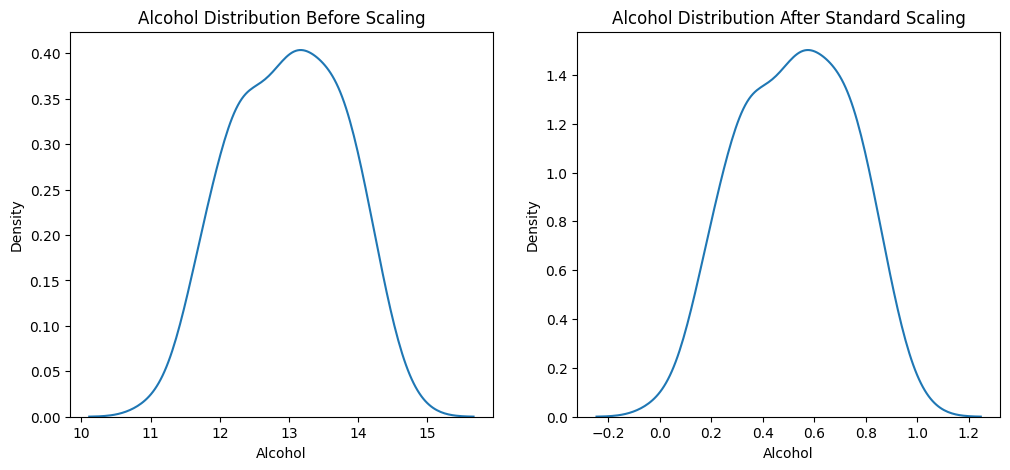

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled_df['Alcohol'], ax=ax2)
plt.show()

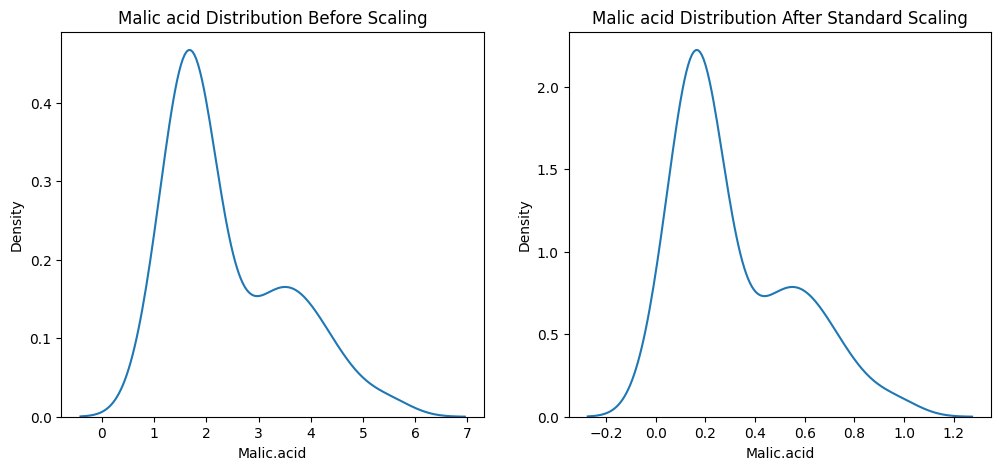

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic.acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled_df['Malic.acid'], ax=ax2)
plt.show()

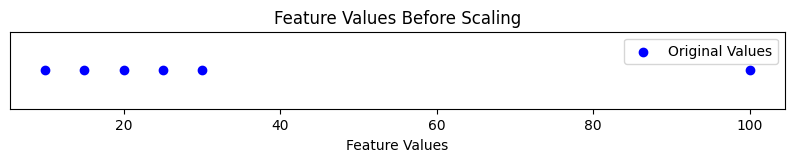

In [23]:
# Sample feature with an outlier
x = np.array([10, 15, 20, 25, 30, 100])

# Plotting the values on a number line
plt.figure(figsize=(10, 1))
plt.scatter(x, [0]*len(x), color='blue', label='Original Values')
plt.title('Feature Values Before Scaling')
plt.yticks([])
plt.xlabel('Feature Values')
plt.legend()
plt.show()

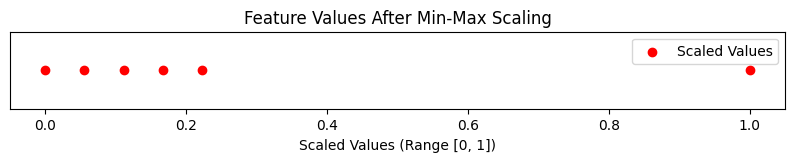

In [22]:
from sklearn.preprocessing import MinMaxScaler

# Reshape the data for MinMaxScaler
x_reshaped = x.reshape(-1, 1)

# Apply Min-Max Scaling
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_reshaped)

# Plotting the scaled values
plt.figure(figsize=(10, 1))
plt.scatter(x_scaled, [0]*len(x_scaled), color='red', label='Scaled Values')
plt.title('Feature Values After Min-Max Scaling')
plt.yticks([])
plt.xlabel('Scaled Values (Range [0, 1])')
plt.legend()
plt.show()